In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

In [277]:
np.random.seed(42)
n_students = 240
student_ids = [f"S{1000+i}" for i in range(n_students)]
students = pd.DataFrame({
"student_id": student_ids,
"gender": np.random.choice(["Female", "Male", "F", "M", "female", "male", None], n_students,
p=[0.28, 0.28, 0.10, 0.10, 0.10, 0.10, 0.04]),
"department": np.random.choice(["AI Engineering", "Computer Engineering", "Software Engineering",
"Industrial Engineering", "AI Eng.", "Comp Eng", None], n_students,
p=[0.30, 0.25, 0.18, 0.15, 0.06, 0.04, 0.02]),
"year": np.random.choice([1, 2, 3, 4], n_students, p=[0.45, 0.35, 0.12, 0.08]),
"scholarship_rate": np.random.choice([0, 25, 50, 75, 100, np.nan], n_students,
p=[0.30, 0.20, 0.20, 0.12, 0.15, 0.03])

})
weeks = pd.date_range("2025-02-03", periods=12, freq="W-MON")
activity_rows = []
for sid in student_ids:
    base_engagement = np.random.normal(6.5, 1.8)
    for week in weeks:
        study_hours = max(0, np.random.normal(base_engagement, 2.0))
        lms_logins = max(0, int(np.random.normal(base_engagement * 2.5, 5)))
        attendance_rate = np.clip(np.random.normal(0.78, 0.18), 0, 1)
        activity_rows.append([sid, week, study_hours, lms_logins, attendance_rate])
        activity = pd.DataFrame(activity_rows, columns=[
        "student_id", "week_start", "study_hours", "lms_logins", "attendance_rate"
])
# Intentional missing values
activity.loc[np.random.choice(activity.index, 50, replace=False), "study_hours"] = np.nan
activity.loc[np.random.choice(activity.index, 40, replace=False), "attendance_rate"] = np.nan
# Intentional impossible values and outliers
activity.loc[np.random.choice(activity.index, 8, replace=False), "study_hours"] = 80
activity.loc[np.random.choice(activity.index, 6, replace=False), "attendance_rate"] = 1.35
activity.loc[np.random.choice(activity.index, 6, replace=False), "lms_logins"] = -5
assessment = pd.DataFrame({
"student_id": student_ids,
"midterm_score": np.random.normal(68, 15, n_students),
"project_score": np.random.normal(72, 14, n_students),
"quiz_average": np.random.normal(70, 13, n_students)
})
# Intentional impossible assessment scores
assessment.loc[np.random.choice(assessment.index, 5, replace=False), "midterm_score"] = 130
assessment.loc[np.random.choice(assessment.index, 5, replace=False), "project_score"] = -10
assessment.loc[np.random.choice(assessment.index, 10, replace=False), "quiz_average"] = np.nan
campus = pd.DataFrame({
"student_id": student_ids,

"club_participation": np.random.choice(["Yes", "No", "yes", "no", "Y", "N", None], n_students,
p=[0.22, 0.38, 0.08, 0.12, 0.07, 0.10, 0.03]),
"library_visits": np.random.poisson(7, n_students),
"advisor_meetings": np.random.poisson(2, n_students)
})
# Generate final score with signal from engagement and assessments
activity_summary = activity.groupby("student_id").agg(
avg_study_hours=("study_hours", "mean"),
avg_lms_logins=("lms_logins", "mean"),
avg_attendance_rate=("attendance_rate", "mean")
).reset_index()
final = students.merge(activity_summary, on="student_id", how="left").merge(assessment, on="student_id",
how="left")
noise = np.random.normal(0, 7, n_students)
final_score = (
0.30 * final["midterm_score"].fillna(final["midterm_score"].median()) +
0.25 * final["project_score"].fillna(final["project_score"].median()) +
0.20 * final["quiz_average"].fillna(final["quiz_average"].median()) +
3.0 * final["avg_study_hours"].fillna(final["avg_study_hours"].median()) +
10.0 * final["avg_attendance_rate"].fillna(final["avg_attendance_rate"].median()) +
noise
)
grades = pd.DataFrame({
"student_id": student_ids,
"final_score": np.clip(final_score, 0, 100)
})
grades["risk_status"] = np.where(grades["final_score"] < 60, "At_Risk", "Not_At_Risk")
# Save raw files
students.to_csv("hw4_students_raw.csv", index=False)
activity.to_csv("hw4_weekly_activity_raw.csv", index=False)
assessment.to_csv("hw4_assessment_raw.csv", index=False)
campus.to_csv("hw4_campus_raw.csv", index=False)
grades.to_csv("hw4_grades_raw.csv", index=False)
print("Synthetic raw datasets created successfully.")

Synthetic raw datasets created successfully.


In [278]:
student_df = pd.read_csv("hw4_students_raw.csv")
w_activity_df = pd.read_csv("hw4_weekly_activity_raw.csv")
assessment_df = pd.read_csv("hw4_assessment_raw.csv")
campus_df = pd.read_csv("hw4_campus_raw.csv")
grades_df = pd.read_csv("hw4_grades_raw.csv")

# Assigning every csv documents to pandas DataFrame.

In [279]:
datas = [student_df, w_activity_df, assessment_df, campus_df, grades_df]
names = ["students", "w_activity", "assessment", "campus", "grades"]

for name, data in zip(names, datas):
    print(f" The shape of {name}: {data.shape}")
#Checking shapes of every datasets.

 The shape of students: (240, 5)
 The shape of w_activity: (2880, 5)
 The shape of assessment: (240, 4)
 The shape of campus: (240, 4)
 The shape of grades: (240, 3)


In [280]:
for name, data in zip(names, datas):
    print(name)
    print(data.head(5))
    print("-"*75)

#priniting all datas in one cell

students
  student_id  gender            department  year  scholarship_rate
0      S1000    Male              Comp Eng     2             100.0
1      S1001    male              Comp Eng     2               0.0
2      S1002       M               AI Eng.     2               0.0
3      S1003       F  Computer Engineering     2              75.0
4      S1004  Female        AI Engineering     2              50.0
---------------------------------------------------------------------------
w_activity
  student_id  week_start  study_hours  lms_logins  attendance_rate
0      S1000  2025-02-03     5.325414          14         0.526801
1      S1000  2025-02-10     4.989714          10         0.604343
2      S1000  2025-02-17     8.943464          12         1.000000
3      S1000  2025-02-24     7.822816          18         0.625496
4      S1000  2025-03-03     8.236800          14         0.801962
---------------------------------------------------------------------------
assessment
  student_id 

In [281]:
for name, data in zip(names, datas):
    print("|" + name + "| Columns |")
    print(data.columns)
    print("-"*90)
#priniting all datas columns in one cell

|students| Columns |
Index(['student_id', 'gender', 'department', 'year', 'scholarship_rate'], dtype='object')
------------------------------------------------------------------------------------------
|w_activity| Columns |
Index(['student_id', 'week_start', 'study_hours', 'lms_logins',
       'attendance_rate'],
      dtype='object')
------------------------------------------------------------------------------------------
|assessment| Columns |
Index(['student_id', 'midterm_score', 'project_score', 'quiz_average'], dtype='object')
------------------------------------------------------------------------------------------
|campus| Columns |
Index(['student_id', 'club_participation', 'library_visits',
       'advisor_meetings'],
      dtype='object')
------------------------------------------------------------------------------------------
|grades| Columns |
Index(['student_id', 'final_score', 'risk_status'], dtype='object')
-------------------------------------------------------------

In [282]:
for name, data in zip(names, datas):
    print("|" + name + "| Columns |")
    print(data.dtypes)
    print("-"*90)
#priniting all datas dtypes in one cell

|students| Columns |
student_id           object
gender               object
department           object
year                  int64
scholarship_rate    float64
dtype: object
------------------------------------------------------------------------------------------
|w_activity| Columns |
student_id          object
week_start          object
study_hours        float64
lms_logins           int64
attendance_rate    float64
dtype: object
------------------------------------------------------------------------------------------
|assessment| Columns |
student_id        object
midterm_score    float64
project_score    float64
quiz_average     float64
dtype: object
------------------------------------------------------------------------------------------
|campus| Columns |
student_id            object
club_participation    object
library_visits         int64
advisor_meetings       int64
dtype: object
------------------------------------------------------------------------------------------
|gr

#TASK1.2
(1)In the student.csv for each unique object represents students and there are 4 (gender,department,year,scholarship_rate) attiributes.

(2) In the w_activity.csv for each unique object(students) again there are 4 (week_start,study_hours,lms_logins,attendance_rate) attributes.

(3) In the assessment.csv for each unique object(students) there are 3
(midterm_score,project_score,quiz_average) attributes.

(4) In the campus.csv for each object(students) there are 3 (club_participation  library_visits,advisor_meetings) attributes.

(5) In the grades.csv for each object(students) there are 2(final_score,  risk_status) attributes.

-------------------------------------------------------------------------------------
1. student_id -> Nominal dtype -> discrete
2. risk_status -> Nominal dtype -> discrete
3. attendance_rate -> Ratio numberic -> continuous
4. week_start -> Date/Time -> discrete
5. lms_logins -> Ratio numeric count -> discrete
6. gender -> Nominal dtype -> discrete
7. library_visits -> Ratio numeric count -> discrete
8. study_hours -> Ratio numeric -> continuous
9. club_participation -> Nominal categorical -> discrete
10. quiz_average -> Ratio numeric -> continuous
-------------------------------------------------------------------------------------

In [283]:
for name, data in zip(names, datas):
    print("Column->" + name)
    print("-"*15)
    print(str(data.isnull().sum()))
    print("-"*25)
#checking weather there is a null or not

Column->students
---------------
student_id          0
gender              8
department          5
year                0
scholarship_rate    3
dtype: int64
-------------------------
Column->w_activity
---------------
student_id          0
week_start          0
study_hours        50
lms_logins          0
attendance_rate    40
dtype: int64
-------------------------
Column->assessment
---------------
student_id        0
midterm_score     0
project_score     0
quiz_average     10
dtype: int64
-------------------------
Column->campus
---------------
student_id            0
club_participation    6
library_visits        0
advisor_meetings      0
dtype: int64
-------------------------
Column->grades
---------------
student_id     0
final_score    0
risk_status    0
dtype: int64
-------------------------


#TASK 1.3

For student.csv there are totally 16 missing values. Most of them is in the gender, then department. For gender i will assing them to unknown. Additionally, for department i will the assign the mode because its not numeric.

For weekly activity there are totally 90 missing 50 hours, 40 attendance rate. For hours i will assign mean s_hours and for attendance rate again mean.

For assessment there are totally 10 missing values all of them in the quiz_avg. I am thinking for quiz_avg and i will assign mean value for missing values.

For Campus there are only 6 missing values and all of them comes from club_participation. Again i will assign the mode for missing values.

For grades thanks to data we dont have any missing values. No need to handle.

The week_start column in the activity dataset requires datetime parsing, addressed in Part 6

In [284]:
datas_modified = [student_df, assessment_df, campus_df, grades_df]
for name, data in zip(names, datas_modified):
    duplicated  = data[data["student_id"].duplicated()]
    print(F"Duplicated Rows length in {name}")
    print(len(duplicated))
    print("-"*70)
#controlling the data in order to find any duplicates
w_activity_dup = w_activity_df.duplicated(subset=["student_id", "week_start"])
print(F"Duplicated Rows length in w_activity")
print(w_activity_dup.sum())
#sum of all duplicates in each data

Duplicated Rows length in students
0
----------------------------------------------------------------------
Duplicated Rows length in w_activity
0
----------------------------------------------------------------------
Duplicated Rows length in assessment
0
----------------------------------------------------------------------
Duplicated Rows length in campus
0
----------------------------------------------------------------------
Duplicated Rows length in w_activity
0


No duplicate student_id records were found in any dataset. Each student appears exactly once across students, assessment, campus, and grades tables. In the activity table, each student_id and week_start combination is unique, confirming 12 weekly records per student.

In [285]:
w_activity_df["attendance_rate"] = round(w_activity_df["attendance_rate"],2)
#There is no chance of students who attended half percent attendence record in history. so i rounded by 2.

assessment_df["midterm_score"] = round(assessment_df["midterm_score"],1)
assessment_df["project_score"] = round(assessment_df["project_score"],1)
assessment_df["quiz_average"] = round(assessment_df["quiz_average"],1)
#Its is more convenient when we use only 1 decimal points
grades_df["quiz_average"] = round(assessment_df["quiz_average"],1)

In [286]:
#Outlier detection and impossible values.
#For student_df
#student_impossible_year = student_df[(1 > student_df["year"]) | (student_df["year"] > 4)]
#print(f"Impossible rows in Student Years: {student_impossible_year}")

#student_impossible_scholarship_rate = student_df[(0.0 > student_df["scholarship_rate"]) | (student_df["scholarship_rate"] > 100.0)]
#print(f"Impossible rows in Student Scholarship_rate: {student_impossible_scholarship_rate

#For w_activity
#date = pd.to_datetime(w_activity_df["week_start"])
#years_impossible = date.dt.year[date.dt.year]
#years_impossible.value_counts()

#study hours
#Q1 = w_activity_df["study_hours"].quantile(0.25)
#Q3 = w_activity_df["study_hours"].quantile(0.75)

#IQR = round(Q3 - Q1, 2)
#Calculatin IQR to eliminate outliers

#Low_boundary = round(Q1 - (3*IQR)/2, 2) 
#Upper_boundary = round(Q3 + (3*IQR)/2, 2) 


#w_activity_Study_H_outliers = w_activity_df[(w_activity_df["study_hours"] < Low_boundary) | (w_activity_df["study_hours"] > Upper_boundary)]
#len(Study_H_outliers) # 23

#lms logins
#Q1 = w_activity_df["lms_logins"].quantile(0.25)
#Q3 = w_activity_df["lms_logins"].quantile(0.75)

#IQR = round(Q3 - Q1, 2)
#Calculatin IQR to eliminate outliers

#Low_boundary = round(Q1 - (3*IQR)/2, 2) 
#Upper_boundary = round(Q3 + (3*IQR)/2, 2) 

#w_activiyt_lms_outliers = w_activity_df[(w_activity_df["lms_logins"] < Low_boundary) | (w_activity_df["lms_logins"] > Upper_boundary)]
#len(w_activiyt_lms_outliers) # 16

#Impossible attendance rates.
#w_acticity_impossible_attendance = w_activity_df[(0.00 > w_activity_df["attendance_rate"]) | (w_activity_df["attendance_rate"] > 1.00)]
#len(w_acticity_impossible_attendance) #6

#Assesment_df
#assessment_impossible_midterm = assessment_df[(0.0 > assessment_df["midterm_score"]) | (assessment_df["midterm_score"] > 100.0)]
#assessment_impossible_project = assessment_df[(0.0 > assessment_df["project_score"]) | (assessment_df["project_score"] > 100.0)]
#assessment_impossible_quiz_avg = assessment_df[(0.0 > assessment_df["quiz_average"]) | (assessment_df["quiz_average"] > 100.0)]
#print(len(assessment_impossible_midterm)) #11
#print(len(assessment_impossible_project)) #9
#print(len(assessment_impossible_quiz_avg)) #

#Campus_df
#library visits
#Q1 = campus_df["library_visits"].quantile(0.25)
#Q3 = campus_df["library_visits"].quantile(0.75)

#IQR = round(Q3 - Q1, 2)
#Calculatin IQR to eliminate outliers

#Low_boundary = round(Q1 - (3*IQR)/2, 2) 
#Upper_boundary = round(Q3 + (3*IQR)/2, 2) 

#campus_library_visit_outliers = campus_df[(campus_df["library_visits"] < Low_boundary) | (campus_df["library_visits"] > Upper_boundary)]
#len(campus_library_visit_outliers) # 0

#Advisor meeting
#Q1 = campus_df["advisor_meetings"].quantile(0.25)
#Q3 = campus_df["advisor_meetings"].quantile(0.75)

#IQR = round(Q3 - Q1, 2)
#Calculatin IQR to eliminate outliers

#Low_boundary = round(Q1 - (3*IQR)/2, 2) 
#Upper_boundary = round(Q3 + (3*IQR)/2, 2) 

#campus_advisor_visit_outliers = campus_df[(campus_df["advisor_meetings"] < Low_boundary) | (campus_df["advisor_meetings"] > Upper_boundary)]
#len(campus_advisor_visit_outliers) #1

#Grades_df

#grades_impossible_fianl_s = grades_df[(0.0 > grades_df["final_score"]) | (grades_df["final_score"] > 100.0)]
#print(len(grades_impossible_fianl_s)) #0

In [287]:
# Invalid Year Analysis
student_impossible_year = student_df[(1 > student_df["year"]) | (student_df["year"] > 4)]
print(f"Impossible rows in Student Years: {len(student_impossible_year)}")
if not student_impossible_year.empty:
    print("Impossible Student Year Rows:")
    print(student_impossible_year)
print("-" * 40)

# Invalid Scholarship Rate Analysis
student_impossible_scholarship_rate = student_df[(0.0 > student_df["scholarship_rate"]) | (student_df["scholarship_rate"] > 100.0)]
print(f"Impossible rows in Student Scholarship Rate: {len(student_impossible_scholarship_rate)}")
if not student_impossible_scholarship_rate.empty:
    print("Impossible Student Scholarship Rate Rows:")
    print(student_impossible_scholarship_rate)
print("\n" + "="*50 + "\n")


# ==========================================
# 2. W_ACTIVITY_DF ANALYSIS
# ==========================================
print("--- W_ACTIVITY_DF ANALYSIS ---")

# Date Analysis (Year check)
date = pd.to_datetime(w_activity_df["week_start"])
print("Weekly Activity Year Distributions:")
print(date.dt.year.value_counts())
print("-" * 40)

# Study Hours Outliers (IQR)
Q1_sh = w_activity_df["study_hours"].quantile(0.25)
Q3_sh = w_activity_df["study_hours"].quantile(0.75)
IQR_sh = round(Q3_sh - Q1_sh, 2)
Low_boundary_sh = round(Q1_sh - (1.5 * IQR_sh), 2)
Upper_boundary_sh = round(Q3_sh + (1.5 * IQR_sh), 2)

w_activity_df["study_hours"] = round(w_activity_df["study_hours"],1)
w_activity_Study_H_outliers = w_activity_df[(w_activity_df["study_hours"] < Low_boundary_sh) | (w_activity_df["study_hours"] > Upper_boundary_sh)]
print(f"Study Hours Outlier Count: {len(w_activity_Study_H_outliers)}")
if not w_activity_Study_H_outliers.empty:
    print("Study Hours Outlier Rows:")
    print(w_activity_Study_H_outliers)
print("-" * 40)

# LMS Logins Outliers (IQR)
Q1_lms = w_activity_df["lms_logins"].quantile(0.25)
Q3_lms = w_activity_df["lms_logins"].quantile(0.75)
IQR_lms = round(Q3_lms - Q1_lms, 2)
Low_boundary_lms = round(Q1_lms - (1.5 * IQR_lms), 2)
Upper_boundary_lms = round(Q3_lms + (1.5 * IQR_lms), 2)

w_activity_lms_outliers = w_activity_df[(w_activity_df["lms_logins"] < Low_boundary_lms) | (w_activity_df["lms_logins"] > Upper_boundary_lms)]
print(f"LMS Logins Outlier Count: {len(w_activity_lms_outliers)}")
if not w_activity_lms_outliers.empty:
    print("LMS Logins Outlier Rows:")
    print(w_activity_lms_outliers)
print("-" * 40)

# Invalid Attendance Rates
w_activity_impossible_attendance = w_activity_df[(0.00 > w_activity_df["attendance_rate"]) | (w_activity_df["attendance_rate"] > 1.00)]
print(f"Impossible Attendance Rate Rows: {len(w_activity_impossible_attendance)}")
if not w_activity_impossible_attendance.empty:
    print("Impossible Attendance Rate Rows:")
    print(w_activity_impossible_attendance)
print("\n" + "="*50 + "\n")


# ==========================================
# 3. ASSESSMENT_DF ANALYSIS
# ==========================================
print("--- ASSESSMENT_DF ANALYSIS ---")

# Midterm Score
assessment_impossible_midterm = assessment_df[(0.0 > assessment_df["midterm_score"]) | (assessment_df["midterm_score"] > 100.0)]
print(f"Impossible Midterm Score Rows: {len(assessment_impossible_midterm)}")
if not assessment_impossible_midterm.empty:
    print("Impossible Midterm Score Rows:")
    print(assessment_impossible_midterm)
print("-" * 40)

# Project Score
assessment_impossible_project = assessment_df[(0.0 > assessment_df["project_score"]) | (assessment_df["project_score"] > 100.0)]
print(f"Impossible Project Score Rows: {len(assessment_impossible_project)}")
if not assessment_impossible_project.empty:
    print("Impossible Project Score Rows:")
    print(assessment_impossible_project)
print("-" * 40)

# Quiz Average
assessment_impossible_quiz_avg = assessment_df[(0.0 > assessment_df["quiz_average"]) | (assessment_df["quiz_average"] > 100.0)]
print(f"Impossible Quiz Average Rows: {len(assessment_impossible_quiz_avg)}")
if not assessment_impossible_quiz_avg.empty:
    print("Impossible Quiz Average Rows:")
    print(assessment_impossible_quiz_avg)
print("\n" + "="*50 + "\n")


# ==========================================
# 4. CAMPUS_DF ANALYSIS
# ==========================================
print("--- CAMPUS_DF ANALYSIS ---")

# Library Visits Outliers (IQR)
Q1_lib = campus_df["library_visits"].quantile(0.25)
Q3_lib = campus_df["library_visits"].quantile(0.75)
IQR_lib = round(Q3_lib - Q1_lib, 2)
Low_boundary_lib = round(Q1_lib - (1.5 * IQR_lib), 2)
Upper_boundary_lib = round(Q3_lib + (1.5 * IQR_lib), 2)

campus_library_visit_outliers = campus_df[(campus_df["library_visits"] < Low_boundary_lib) | (campus_df["library_visits"] > Upper_boundary_lib)]
print(f"Library Visits Outlier Count: {len(campus_library_visit_outliers)}")
if not campus_library_visit_outliers.empty:
    print("Library Visits Outlier Rows:")
    print(campus_library_visit_outliers)
print("-" * 40)

# Advisor Meetings Outliers (IQR)
Q1_adv = campus_df["advisor_meetings"].quantile(0.25)
Q3_adv = campus_df["advisor_meetings"].quantile(0.75)
IQR_adv = round(Q3_adv - Q1_adv, 2)
Low_boundary_adv = round(Q1_adv - (1.5 * IQR_adv), 2)
Upper_boundary_adv = round(Q3_adv + (1.5 * IQR_adv), 2)

campus_advisor_visit_outliers = campus_df[(campus_df["advisor_meetings"] < Low_boundary_adv) | (campus_df["advisor_meetings"] > Upper_boundary_adv)]
print(f"Advisor Meetings Outlier Count: {len(campus_advisor_visit_outliers)}")
if not campus_advisor_visit_outliers.empty:
    print("Advisor Meetings Outlier Rows:")
    print(campus_advisor_visit_outliers)
print("\n" + "="*50 + "\n")


# ==========================================
# 5. GRADES_DF ANALYSIS
# ==========================================
print("--- GRADES_DF ANALYSIS ---")

# Final Score
grades_impossible_final_s = grades_df[(0.0 > grades_df["final_score"]) | (grades_df["final_score"] > 100.0)]
print(f"Impossible Final Score Rows: {len(grades_impossible_final_s)}")
if not grades_impossible_final_s.empty:
    print("Impossible Final Score Rows:")
    print(grades_impossible_final_s)
print("\n" + "="*50)

#For this part i detect outliers and extreme values. I used IQR and spesific ranges like [0,100] then 
#showed each impossible rows then counted.


#In one earlier cell i did everything by myself but for better visualization
#i asked llm to make beautify. It added the name of the part i deal with. It did not changed my code just visualization.
# My code stays in one earlier cell!

Impossible rows in Student Years: 0
----------------------------------------
Impossible rows in Student Scholarship Rate: 0


--- W_ACTIVITY_DF ANALYSIS ---
Weekly Activity Year Distributions:
week_start
2025    2880
Name: count, dtype: int64
----------------------------------------
Study Hours Outlier Count: 23
Study Hours Outlier Rows:
     student_id  week_start  study_hours  lms_logins  attendance_rate
64        S1005  2025-03-03         13.6          19             0.51
125       S1010  2025-03-10         14.1          29             0.74
128       S1010  2025-03-31         13.6          26             0.80
539       S1044  2025-04-21         80.0          15             0.93
704       S1058  2025-03-31         80.0          20             1.00
854       S1071  2025-02-17         14.1          30             0.82
860       S1071  2025-03-31         14.3          22             0.87
924       S1077  2025-02-03         80.0          26             0.84
977       S1081  2025-03-10   

In [288]:
#Inconsistent categorial labels.

print(student_df["gender"].value_counts())
print("-" * 40)
print(campus_df["club_participation"].value_counts())
print("-" * 40)
print(student_df["department"].value_counts())

gender
Female    75
Male      63
F         27
male      26
female    21
M         20
Name: count, dtype: int64
----------------------------------------
club_participation
No     87
Yes    52
no     31
yes    27
Y      20
N      17
Name: count, dtype: int64
----------------------------------------
department
AI Engineering            68
Computer Engineering      58
Software Engineering      40
Industrial Engineering    39
Comp Eng                  17
AI Eng.                   13
Name: count, dtype: int64


#Task 1.3 Insights

This data quality analysis checks five interconnected datasets (student_df, w_activity_df, assessment_df, campus_df, and grades_df) to identify and isolate logical anomalies, statistical outliers, and categorical inconsistencies. It parses the week_start column into datetime format to verify timeline consistency and flag any unexpected years, while scanning for impossible values that defy real-world boundaries—such as academic years outside the 1–4 range, scholarship or grade rates escaping the 0–100 scale, and attendance percentages dropping below 0.0 or exceeding 1.0. For behavioral metrics like study hours, LMS logins, library visits, and advisor meetings, the script calculates the Interquartile Range (IQR) with standard whiskers (1.5×IQR) to flag extreme statistical outliers. Finally, it uses frequency distributions to check categorical columns (gender, club_participation, and department) for structural text issues like typos, mixed casing, or inconsistent naming conventions that could corrupt future analytical models.

In [289]:
#Task 2

In [290]:
student_df["gender"].value_counts()
#Checking beforehand to know unique values.

gender
Female    75
Male      63
F         27
male      26
female    21
M         20
Name: count, dtype: int64

In [291]:
student_df["department"].value_counts()
#Checking beforehand to know unique values.

department
AI Engineering            68
Computer Engineering      58
Software Engineering      40
Industrial Engineering    39
Comp Eng                  17
AI Eng.                   13
Name: count, dtype: int64

In [292]:
campus_df["club_participation"].value_counts()
#Checking beforehand to know unique values.

club_participation
No     87
Yes    52
no     31
yes    27
Y      20
N      17
Name: count, dtype: int64

In [293]:
Standardize_map_gender = {
    "Male" : "M",
    "male" : "M",
    "M" : "M",
    "F" : "F",
    "Female" : "F",
    "female" : "F"
}
student_df["gender"] = student_df["gender"].map(Standardize_map_gender)
print(f"Unique genders:   {student_df["gender"].unique()}")

Standardize_map_department = {
    "Comp Eng" : "Computer Engineering",
    "AI Eng" : "AI Engineering",
    "Computer Engineering" : "Computer Engineering",
    "AI Engineering" : "AI Engineering",
    "Industrial Engineering" : "Industrial Engineering",
    "Software Engineering" : "Software Engineering"
}
student_df["department"] = student_df["department"].map(Standardize_map_department)
print(f"Unique departments:   {student_df["department"].unique()}")

Standardize_map_club_participation =  {
    "Yes" : "Y",
    "yes" : "Y",
    "Y" : "Y",
    "No" : "N",
    "no" : "N",
    "N" : "N"
}
campus_df["club_participation"] = campus_df["club_participation"].map(Standardize_map_club_participation)
print(f"Unique club_participation:   {campus_df["club_participation"].unique()}")

#using map i assigned new values for each row pf the column. 
#For example, there are too many derivative of Male and Female

Unique genders:   ['M' 'F' nan]
Unique departments:   ['Computer Engineering' nan 'AI Engineering' 'Industrial Engineering'
 'Software Engineering']
Unique club_participation:   ['Y' 'N' nan]


In [294]:
print(student_df["gender"].value_counts())
print(student_df["department"].value_counts())
print(campus_df["club_participation"].value_counts())
#Checking all the datas to be sure we handeled correct

gender
F    123
M    109
Name: count, dtype: int64
department
Computer Engineering      75
AI Engineering            68
Software Engineering      40
Industrial Engineering    39
Name: count, dtype: int64
club_participation
N    135
Y     99
Name: count, dtype: int64


In [295]:
#Task 2.2

In [296]:
student_df["gender"] = student_df["gender"].fillna("Gender-Unknown")
print(student_df["gender"].value_counts())
# Because of we dont know gender the best approach should be assigning to unknown. For all 3 cases.
print("-" * 40)
student_df["department"] = student_df["department"].fillna("Dep-Unknown")
print(student_df["department"].value_counts())
print("-" * 40)
campus_df["club_participation"] = campus_df["club_participation"].fillna("Club-Unknown")
print(campus_df["club_participation"].value_counts())

#In here i assigned as Unknown because deleting rows for only 1 missing/malformed/outlier shouldn't affect entire row then i changed as unknown.


gender
F                 123
M                 109
Gender-Unknown      8
Name: count, dtype: int64
----------------------------------------
department
Computer Engineering      75
AI Engineering            68
Software Engineering      40
Industrial Engineering    39
Dep-Unknown               18
Name: count, dtype: int64
----------------------------------------
club_participation
N               135
Y                99
Club-Unknown      6
Name: count, dtype: int64


In [297]:
#Task 2.3 has to executed first before 2.2 because i dont want median affected by outliers.


In [298]:
w_activity_df["study_hours"] = w_activity_df["study_hours"].replace(80, np.nan)
w_activity_df["study_hours"] = round(w_activity_df["study_hours"], 1)
w_activity_df
#Values above the IQR upper boundary were reviewed manually. Only the value of 80 was treated as impossible
#and replaced with NaN as weekly study hours of 13-16 are realistic for university students.

,student_id,week_start,study_hours,lms_logins,attendance_rate
0,S1000,2025-02-03,5.3,14,0.53
1,S1000,2025-02-10,5.0,10,0.60
2,S1000,2025-02-17,8.9,12,1.00
3,S1000,2025-02-24,7.8,18,0.63
4,S1000,2025-03-03,8.2,14,0.80
...,...,...,...,...,...
2875,S1239,2025-03-24,NaN,17,0.44
2876,S1239,2025-03-31,7.0,21,0.96
2877,S1239,2025-04-07,5.6,24,0.66
2878,S1239,2025-04-14,8.7,17,0.81


In [299]:
w_activity_df.loc[w_activity_lms_outliers.index, "lms_logins"] = np.nan
#After i found outliers i used .loc[index_version_outlier, column] = np.nan
w_activity_df.loc[w_activity_impossible_attendance.index, "attendance_rate"] = np.nan
assessment_df.loc[assessment_impossible_midterm.index, "midterm_score"] = np.nan
assessment_df.loc[assessment_impossible_project.index, "project_score"] = np.nan
assessment_df.loc[assessment_impossible_quiz_avg.index, "quiz_average"] = np.nan

final_score_immposible = grades_df[(0.0 > grades_df["final_score"]) | (grades_df["final_score"] > 100.0)]
#print(final_score_immposible) # No single row in here so no need to fix anything
#In here i detect all impossible scenarios including outliers, missing data, malformed data. this detection done in earlier cells where everything handeled.
#After careful examination i came across some negative values, extreme values... in here i turn all of them into nan. Also some of the addendance rates was outside of the 
#normal fixed interval. Additionally, exam scores, project score all of them handeled and tured into unknown category. Lastly, i checked dates to make it more reliable
assessment_df.isnull().sum()

student_id        0
midterm_score    11
project_score     9
quiz_average     15
dtype: int64

In [300]:
student_df["scholarship_rate"] = student_df["scholarship_rate"].fillna(np.nanmedian(student_df["scholarship_rate"]))
print(student_df["scholarship_rate"].value_counts())
print("-" * 40)
w_activity_df["study_hours"] = w_activity_df["study_hours"].fillna(np.nanmedian(w_activity_df["study_hours"]))
print(w_activity_df["study_hours"].value_counts())
print("-" * 40)
w_activity_df["attendance_rate"] = w_activity_df["attendance_rate"].fillna(np.nanmedian(w_activity_df["attendance_rate"]))
print(w_activity_df["attendance_rate"].value_counts())
print("-" * 40)
assessment_df["quiz_average"] = assessment_df["quiz_average"].fillna(np.nanmedian(assessment_df["quiz_average"]))
print(assessment_df["quiz_average"].value_counts())
print("-" * 40)
assessment_df["midterm_score"] = assessment_df["midterm_score"].fillna(np.nanmedian(assessment_df["midterm_score"]))
print("-" * 40)
assessment_df["project_score"] = assessment_df["project_score"].fillna(np.nanmedian(assessment_df["project_score"]))

#Task 2.2 is after 2.3, i stated why after in earlier cells.
#In here i selected all NaN values across all related columns then used fillna to assing values i used median its not affected by outliers.

scholarship_rate
0.0      78
50.0     51
25.0     47
100.0    39
75.0     25
Name: count, dtype: int64
----------------------------------------
study_hours
6.2     107
6.0      53
5.2      52
5.9      51
6.1      51
       ... 
13.4      1
14.2      1
15.8      1
12.3      1
14.6      1
Name: count, Length: 140, dtype: int64
----------------------------------------
attendance_rate
1.00    354
0.78    116
0.73     77
0.82     68
0.74     68
       ... 
0.24      1
0.26      1
0.37      1
0.27      1
0.13      1
Name: count, Length: 76, dtype: int64
----------------------------------------
quiz_average
71.3    17
68.2     3
77.2     3
64.6     3
71.2     3
        ..
96.8     1
73.6     1
47.3     1
80.2     1
66.4     1
Name: count, Length: 174, dtype: int64
----------------------------------------
----------------------------------------


In [301]:
#Task 2.4

In [302]:
student_df.to_csv("hw4_cleaned_student_df.csv", index=False)
w_activity_df.to_csv("hw4_cleaned_w_activitiy_df.csv", index=False)
assessment_df.to_csv("hw4_cleaned_assessment_df.csv", index=False)
campus_df.to_csv("hw4_cleaned_campus_df.csv", index=False)
grades_df.to_csv("hw4_cleaned_grades_df.csv", index=False)
#Saving all df as csv file.

In [303]:
map_ = {
  "study_hours": ["mean", "sum"],
  "lms_logins": ["mean", "sum"],
  "attendance_rate": ["mean"],
  "week_start": ["count"]
}
new_w_activity_df = w_activity_df.groupby("student_id").agg(map_)
#Whit this we reduced row count by 12 there were 12 records for each student. 
#After performing these code there will be only one line for each student.
new_w_activity_df.columns = ["_".join(col) for col in new_w_activity_df.columns]
new_w_activity_df

,study_hours_mean,study_hours_sum,lms_logins_mean,lms_logins_sum,attendance_rate_mean,week_start_count
student_id,,,,,,
S1000,7.125000,85.5,15.083333,181.0,0.817500,12
S1001,8.050000,96.6,18.833333,226.0,0.787500,12
S1002,5.450000,65.4,13.500000,162.0,0.818333,12
S1003,7.316667,87.8,21.333333,256.0,0.844167,12
S1004,9.766667,117.2,21.750000,261.0,0.806667,12
...,...,...,...,...,...,...
S1235,5.775000,69.3,13.916667,167.0,0.774167,12
S1236,6.766667,81.2,16.583333,199.0,0.811667,12
S1237,4.600000,55.2,10.416667,125.0,0.776667,12


In [304]:
#Task3.2

In [305]:
merged_df = pd.merge(student_df,assessment_df, on = "student_id", how = "left")
merged_df = pd.merge(merged_df,campus_df, on = "student_id", how = "left")
merged_df = pd.merge(merged_df,new_w_activity_df, on = "student_id", how = "left")
merged_df = pd.merge(merged_df,grades_df, on = "student_id", how = "left")
merged_df.shape
#merging files into a one file.

(240, 20)

In [306]:
merged_df

,student_id,gender,department,year,scholarship_rate,midterm_score,project_score,quiz_average_x,club_participation,library_visits,advisor_meetings,study_hours_mean,study_hours_sum,lms_logins_mean,lms_logins_sum,attendance_rate_mean,week_start_count,final_score,risk_status,quiz_average_y
0,S1000,M,Computer Engineering,2,100.0,43.9,93.7,73.4,Y,13,1,7.125000,85.5,15.083333,181.0,0.817500,12,86.443755,Not_At_Risk,73.4
1,S1001,M,Computer Engineering,2,0.0,67.3,60.9,76.8,N,6,2,8.050000,96.6,18.833333,226.0,0.787500,12,78.634579,Not_At_Risk,76.8
2,S1002,M,Dep-Unknown,2,0.0,49.9,76.6,83.1,N,4,1,5.450000,65.4,13.500000,162.0,0.818333,12,56.559696,At_Risk,83.1
3,S1003,F,Computer Engineering,2,75.0,70.1,42.2,82.0,N,9,5,7.316667,87.8,21.333333,256.0,0.844167,12,86.158871,Not_At_Risk,82.0
4,S1004,F,AI Engineering,2,50.0,56.6,66.5,59.6,Y,1,1,9.766667,117.2,21.750000,261.0,0.806667,12,68.606180,Not_At_Risk,59.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,S1235,M,Dep-Unknown,4,25.0,85.8,49.3,66.5,Y,5,0,5.775000,69.3,13.916667,167.0,0.774167,12,71.222566,Not_At_Risk,66.5
236,S1236,M,AI Engineering,3,50.0,74.2,87.4,60.5,N,11,0,6.766667,81.2,16.583333,199.0,0.811667,12,84.638368,Not_At_Risk,60.5
237,S1237,F,Software Engineering,4,0.0,65.5,73.4,60.8,N,9,3,4.600000,55.2,10.416667,125.0,0.776667,12,72.375301,Not_At_Risk,60.8
238,S1238,F,Computer Engineering,1,0.0,78.3,85.6,71.5,Y,4,2,8.075000,96.9,17.333333,208.0,0.639167,12,89.100227,Not_At_Risk,71.5


In [307]:
merged_df = merged_df.drop(columns=['quiz_average_y'])
merged_df
#there were 2 identical columns so i droped oen of them.

,student_id,gender,department,year,scholarship_rate,midterm_score,project_score,quiz_average_x,club_participation,library_visits,advisor_meetings,study_hours_mean,study_hours_sum,lms_logins_mean,lms_logins_sum,attendance_rate_mean,week_start_count,final_score,risk_status
0,S1000,M,Computer Engineering,2,100.0,43.9,93.7,73.4,Y,13,1,7.125000,85.5,15.083333,181.0,0.817500,12,86.443755,Not_At_Risk
1,S1001,M,Computer Engineering,2,0.0,67.3,60.9,76.8,N,6,2,8.050000,96.6,18.833333,226.0,0.787500,12,78.634579,Not_At_Risk
2,S1002,M,Dep-Unknown,2,0.0,49.9,76.6,83.1,N,4,1,5.450000,65.4,13.500000,162.0,0.818333,12,56.559696,At_Risk
3,S1003,F,Computer Engineering,2,75.0,70.1,42.2,82.0,N,9,5,7.316667,87.8,21.333333,256.0,0.844167,12,86.158871,Not_At_Risk
4,S1004,F,AI Engineering,2,50.0,56.6,66.5,59.6,Y,1,1,9.766667,117.2,21.750000,261.0,0.806667,12,68.606180,Not_At_Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,S1235,M,Dep-Unknown,4,25.0,85.8,49.3,66.5,Y,5,0,5.775000,69.3,13.916667,167.0,0.774167,12,71.222566,Not_At_Risk
236,S1236,M,AI Engineering,3,50.0,74.2,87.4,60.5,N,11,0,6.766667,81.2,16.583333,199.0,0.811667,12,84.638368,Not_At_Risk
237,S1237,F,Software Engineering,4,0.0,65.5,73.4,60.8,N,9,3,4.600000,55.2,10.416667,125.0,0.776667,12,72.375301,Not_At_Risk
238,S1238,F,Computer Engineering,1,0.0,78.3,85.6,71.5,Y,4,2,8.075000,96.9,17.333333,208.0,0.639167,12,89.100227,Not_At_Risk


In [308]:
merged_df = merged_df.rename(columns={'quiz_average_x': 'quiz_average'})
#i changed the name of the quiz_average_x because there only 1 column

In [309]:
merged_df.to_csv("hw4_cleaned_student_analytics.csv", index=False)

In [310]:
merged_df["high_attendance"] = np.where(merged_df["attendance_rate_mean"] >= 0.80, 1, 0)
#selecting and assigning new values for high_attendance.1, 0 version is better to predict.

In [311]:
from sklearn.preprocessing import LabelEncoder

merged_df["high_study_hours"] = np.where(merged_df["study_hours_sum"] >= 95.0, 1, 0)
#if the student has more study hours than 95 hours S/he becames high_study_hours -> 1
merged_df["engagement_score"] = (
    (merged_df["midterm_score"] * 0.3) +
    (merged_df["project_score"] * 0.3) +
    (merged_df["quiz_average"] * 0.2) +  
    (merged_df["library_visits"] * 0.05) +
    (merged_df["lms_logins_mean"] * 0.05) +
    (merged_df["attendance_rate_mean"] * 10)
).round(1)
#calculating engeagement score for each student. This shows that each students total engeagement to university.
le = LabelEncoder()
merged_df["risk_status_encoded"] = le.fit_transform(merged_df["risk_status"])
print(le.classes_)
#At_risk = 0, Not_At_Risk = 1
#Also we are going to need to predict status in future so 1, 0 version is better.

merged_df["active_campus_user"] = np.where((merged_df["club_participation"] == "Y") & (merged_df["library_visits"] >= 8) & 
                                           (merged_df["lms_logins_sum"] >= 175), 1, 0)
#calculating active campus user using np.where. this gives an idea about student wheather s/he is active or pasif campus user.
merged_df

['At_Risk' 'Not_At_Risk']


,student_id,gender,department,year,scholarship_rate,midterm_score,project_score,quiz_average,club_participation,library_visits,...,lms_logins_sum,attendance_rate_mean,week_start_count,final_score,risk_status,high_attendance,high_study_hours,engagement_score,risk_status_encoded,active_campus_user
0,S1000,M,Computer Engineering,2,100.0,43.9,93.7,73.4,Y,13,...,181.0,0.817500,12,86.443755,Not_At_Risk,1,0,65.5,1,1
1,S1001,M,Computer Engineering,2,0.0,67.3,60.9,76.8,N,6,...,226.0,0.787500,12,78.634579,Not_At_Risk,0,1,62.9,1,0
2,S1002,M,Dep-Unknown,2,0.0,49.9,76.6,83.1,N,4,...,162.0,0.818333,12,56.559696,At_Risk,1,0,63.6,0,0
3,S1003,F,Computer Engineering,2,75.0,70.1,42.2,82.0,N,9,...,256.0,0.844167,12,86.158871,Not_At_Risk,1,0,60.0,1,0
4,S1004,F,AI Engineering,2,50.0,56.6,66.5,59.6,Y,1,...,261.0,0.806667,12,68.606180,Not_At_Risk,1,1,58.1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,S1235,M,Dep-Unknown,4,25.0,85.8,49.3,66.5,Y,5,...,167.0,0.774167,12,71.222566,Not_At_Risk,0,0,62.5,1,0
236,S1236,M,AI Engineering,3,50.0,74.2,87.4,60.5,N,11,...,199.0,0.811667,12,84.638368,Not_At_Risk,1,0,70.1,1,0
237,S1237,F,Software Engineering,4,0.0,65.5,73.4,60.8,N,9,...,125.0,0.776667,12,72.375301,Not_At_Risk,0,0,62.6,1,0
238,S1238,F,Computer Engineering,1,0.0,78.3,85.6,71.5,Y,4,...,208.0,0.639167,12,89.100227,Not_At_Risk,0,1,70.9,1,0


In [312]:
#Task 3.4

In [313]:
task_3_4 = merged_df.groupby(["department","year"])["final_score"].mean().unstack().round(1)
task_3_4
#Creating tables using groupby. By the time passes ai and computer eng. tens to increase their final score.

year,1,2,3,4
department,,,,
AI Engineering,81.4,76.8,82.6,83.2
Computer Engineering,79.4,79.2,78.1,84.0
Dep-Unknown,80.0,82.3,81.8,71.2
Industrial Engineering,83.3,76.2,82.8,81.2
Software Engineering,75.5,82.6,82.7,81.8


In [314]:
merged_df.columns

Index(['student_id', 'gender', 'department', 'year', 'scholarship_rate',
       'midterm_score', 'project_score', 'quiz_average', 'club_participation',
       'library_visits', 'advisor_meetings', 'study_hours_mean',
       'study_hours_sum', 'lms_logins_mean', 'lms_logins_sum',
       'attendance_rate_mean', 'week_start_count', 'final_score',
       'risk_status', 'high_attendance', 'high_study_hours',
       'engagement_score', 'risk_status_encoded', 'active_campus_user'],
      dtype='object')

In [315]:
merged_df[["study_hours_mean", "lms_logins_sum", "attendance_rate_mean", "midterm_score", "project_score", "quiz_average", "final_score", 
          "library_visits", "advisor_meetings"]].describe().round(1)
#descriptive statistics part

,study_hours_mean,lms_logins_sum,attendance_rate_mean,midterm_score,project_score,quiz_average,final_score,library_visits,advisor_meetings
count,240.0,240.0,240.0,240.0,240.0,240.0,240.0,240.0,240.0
mean,6.3,182.9,0.8,66.5,71.2,70.5,79.8,7.0,2.1
std,1.8,54.1,0.0,13.1,12.7,11.9,11.3,2.7,1.4
min,0.8,32.0,0.6,40.1,36.6,37.1,44.1,1.0,0.0
25%,5.1,148.0,0.7,56.8,63.7,62.8,72.4,5.0,1.0
50%,6.2,181.0,0.8,65.5,71.3,71.3,79.5,7.0,2.0
75%,7.5,218.5,0.8,76.8,79.5,77.2,86.2,9.0,3.0
max,11.2,308.0,0.9,100.0,99.5,98.6,100.0,15.0,7.0


In [316]:
my_list = [
    "gender",
    "department",
    "year",
    "club_participation",
    "risk_status",
    "active_campus_user"
]
for col in my_list:
    print("-" * 20)
    print(merged_df[col].value_counts())

    #for each  categorial column there is frequency  table

--------------------
gender
F                 123
M                 109
Gender-Unknown      8
Name: count, dtype: int64
--------------------
department
Computer Engineering      75
AI Engineering            68
Software Engineering      40
Industrial Engineering    39
Dep-Unknown               18
Name: count, dtype: int64
--------------------
year
1    111
2     81
3     26
4     22
Name: count, dtype: int64
--------------------
club_participation
N               135
Y                99
Club-Unknown      6
Name: count, dtype: int64
--------------------
risk_status
Not_At_Risk    228
At_Risk         12
Name: count, dtype: int64
--------------------
active_campus_user
0    216
1     24
Name: count, dtype: int64


In [317]:
group_based = merged_df.groupby("department")[["final_score", "risk_status_encoded"]].mean().round(1)
group_based
#group_based_analysis

,final_score,risk_status_encoded
department,,
AI Engineering,79.7,1.0
Computer Engineering,79.7,1.0
Dep-Unknown,80.7,0.9
Industrial Engineering,81.0,0.9
Software Engineering,78.6,0.9


In [318]:
group_based_2= merged_df.groupby("year")[["final_score", "risk_status_encoded"]].mean().round(1)
group_based_2
#group_based_analysis

,final_score,risk_status_encoded
year,,
1,79.8,0.9
2,78.5,0.9
3,82.0,1.0
4,82.2,1.0


In [319]:
group_based_3= merged_df.groupby("gender")[["final_score", "risk_status_encoded"]].mean().round(1)
group_based_3
#group_based_analysis

,final_score,risk_status_encoded
gender,,
F,79.6,1.0
Gender-Unknown,81.4,1.0
M,80.0,0.9


In [320]:
group_based_4= merged_df.groupby("club_participation")[["final_score", "risk_status_encoded"]].mean().round(1)
group_based_4
#group_based_analysis

,final_score,risk_status_encoded
club_participation,,
Club-Unknown,80.5,1.0
N,78.9,0.9
Y,81.0,1.0


In [321]:
group_based_5= merged_df.groupby("high_attendance")[["final_score", "risk_status_encoded"]].mean().round(1)
group_based_5
#group_based_analysis

,final_score,risk_status_encoded
high_attendance,,
0,80.4,1.0
1,78.3,0.9


Surprisingly, students with lower attendance showed higher final scores and lower risk rates.
This may suggest that high-performing students attend selectively or rely on self-study
Or in the raw data something went wrong thats why we got something like this result.
I calculated manually after and because of the numbers very close i think python just ignores them

In [322]:
group_based_6= merged_df.groupby("engagement_score")[["final_score", "risk_status_encoded"]].mean().round(1)
group_based_6 
#group_based_analysis

,final_score,risk_status_encoded
engagement_score,,
47.5,71.0,1.0
50.3,67.4,1.0
50.5,74.0,1.0
51.4,73.1,1.0
53.2,63.7,1.0
...,...,...
76.6,100.0,1.0
77.3,91.3,1.0
79.1,100.0,1.0


In [323]:
#Task 5

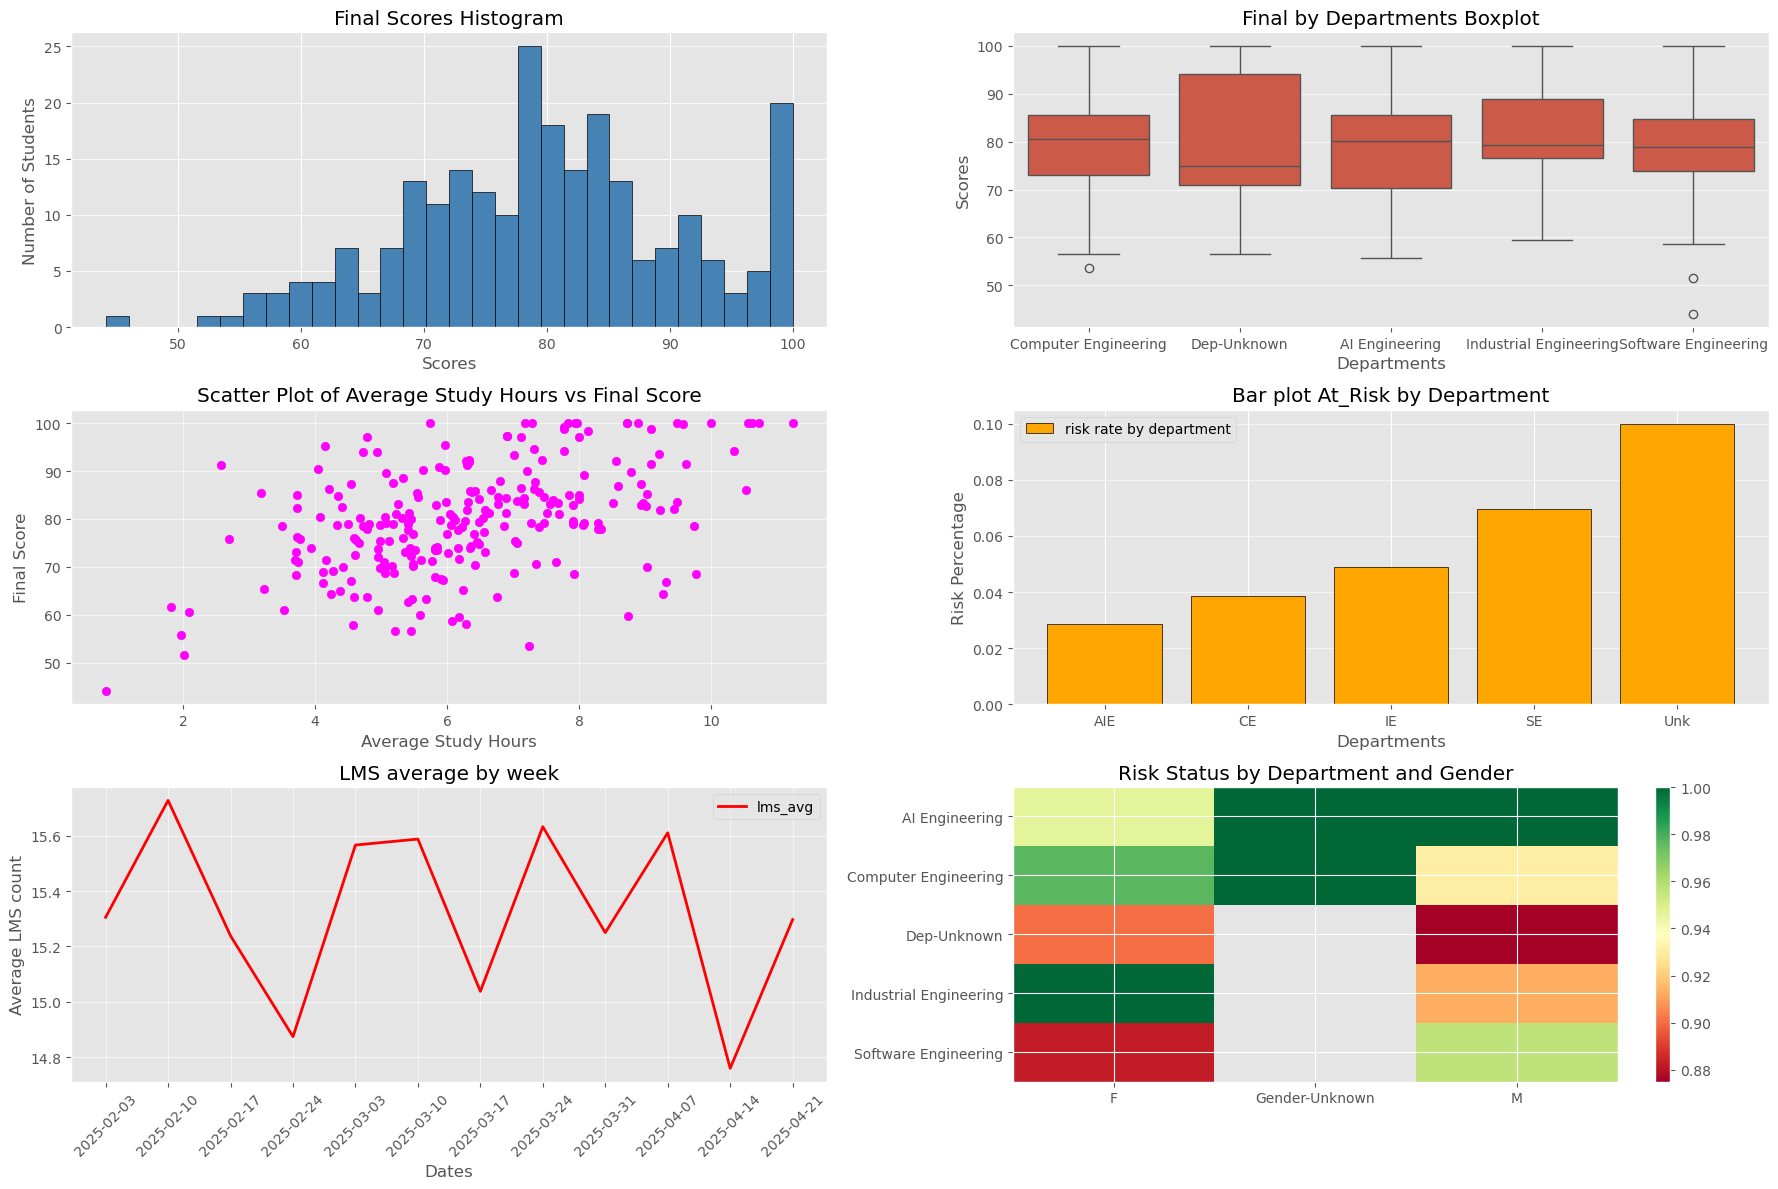

In [324]:
import seaborn as sns
fig, ax = plt.subplots(3, 2, figsize=(18, 12))
#i crated subplots to see all in one
ax = ax.flatten()
#it turns into a one line series rather than 2 by 3 matris.
ax[0].hist(merged_df["final_score"], bins = 30, color ="steelblue", edgecolor = "black")
ax[0].grid(True, axis = "y", alpha = 0.7)
ax[0].set_title("Final Scores Histogram")
ax[0].set_xlabel("Scores")
ax[0].set_ylabel("Number of Students")
# first graph is histogram
sns.boxplot(data = merged_df, x = "department", y = "final_score", ax = ax[1])
ax[1].grid(True, axis = "y", alpha = 0.7)
ax[1].set_title("Final by Departments Boxplot")
ax[1].set_xlabel("Departments")
ax[1].set_ylabel("Scores")
#Using seaborn is easier than pure matplotlib in here.
#second graph is boxplot
ax[2].scatter(merged_df["study_hours_mean"], merged_df["final_score"], color = "magenta")
ax[2].grid(True, alpha = 0.6)
ax[2].set_title("Scatter Plot of Average Study Hours vs Final Score")
ax[2].set_xlabel("Average Study Hours")
ax[2].set_ylabel("Final Score")
#third graph is scatter
department_names = ["AIE", "CE", "IE", "SE", "Unk"]
#I used acronyms for better visualizations.
risk_rate = [2/70, 3/78, 2/41, 3/43, 2/20]
#I check all of them manually then hardcoded.

ax[3].bar(department_names, risk_rate, color = "orange", label = "risk rate by department", edgecolor = "black")
ax[3].grid(True, alpha = 0.6, axis ="y")
ax[3].set_title("Bar plot At_Risk by Department")
ax[3].set_xlabel("Departments")
ax[3].set_ylabel("Risk Percentage")
ax[3].legend()
#forth graph is bar

df_week_lms = w_activity_df.groupby("week_start")["lms_logins"].mean()

ax[4].plot(df_week_lms, color = "red", linewidth = 2, label = "lms_avg")
ax[4].tick_params(axis='x', rotation=45)
ax[4].grid(True, alpha = 0.6)
ax[4].set_title("LMS average by week")
ax[4].set_xlabel("Dates")
ax[4].set_ylabel("Average LMS count")
ax[4].legend()
#fifth graph is regular plot
group_based_n = merged_df.groupby(["department", "gender"])["risk_status_encoded"].mean().unstack()
im = ax[5].imshow(group_based_n, cmap="RdYlGn", aspect="auto")
plt.colorbar(im, ax=ax[5])
ax[5].set_xticks(range(len(group_based_n.columns)))
ax[5].set_yticks(range(len(group_based_n.index)))
ax[5].set_xticklabels(group_based_n.columns)
ax[5].set_yticklabels(group_based_n.index)
ax[5].set_title("Risk Status by Department and Gender")
#sixth graph is heatmap-like

#for all i assinged a x_label, y_labe, title and for some label with legend not all because for some of them unnecessary. 
#Lastly, i put grid
plt.tight_layout()

In [325]:
#Task 6

In [326]:
#I convert week_start in earlier cell but to show im going to do again.
w_activity_df["week_start"].info()
#object.

<class 'pandas.core.series.Series'>
RangeIndex: 2880 entries, 0 to 2879
Series name: week_start
Non-Null Count  Dtype 
--------------  ----- 
2880 non-null   object
dtypes: object(1)
memory usage: 22.6+ KB


In [327]:
date.info()
#The converted version. I converted to datetime when i was analyzing data frames.

<class 'pandas.core.series.Series'>
RangeIndex: 2880 entries, 0 to 2879
Series name: week_start
Non-Null Count  Dtype         
--------------  -----         
2880 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 22.6 KB


In [328]:
print(f" first record of time: {date.min()}")
print(f" last record of time: {date.max()}")

 first record of time: 2025-02-03 00:00:00
 last record of time: 2025-04-21 00:00:00


In [329]:
print(f" unique weeks : {w_activity_df["week_start"].nunique()}")
print(f" values counts of week: {w_activity_df["week_start"].value_counts()}")

 unique weeks : 12
 values counts of week: week_start
2025-02-03    240
2025-02-10    240
2025-02-17    240
2025-02-24    240
2025-03-03    240
2025-03-10    240
2025-03-17    240
2025-03-24    240
2025-03-31    240
2025-04-07    240
2025-04-14    240
2025-04-21    240
Name: count, dtype: int64


In [330]:
date = pd.DataFrame(date)
#date.head()
indx_date = date.set_index("week_start")
indx_date.head()

""
week_start
2025-02-03
2025-02-10
2025-02-17
2025-02-24
2025-03-03


In [331]:
indx_date.loc["2025-02-03"].head()
#I selected 3 to 10 th days of the week.

""
week_start
2025-02-03
2025-02-03
2025-02-03
2025-02-03
2025-02-03


In [332]:
indx_date.sort_index().head()
#sorted by index.

""
week_start
2025-02-03
2025-02-03
2025-02-03
2025-02-03
2025-02-03


In [333]:
#task 6.3

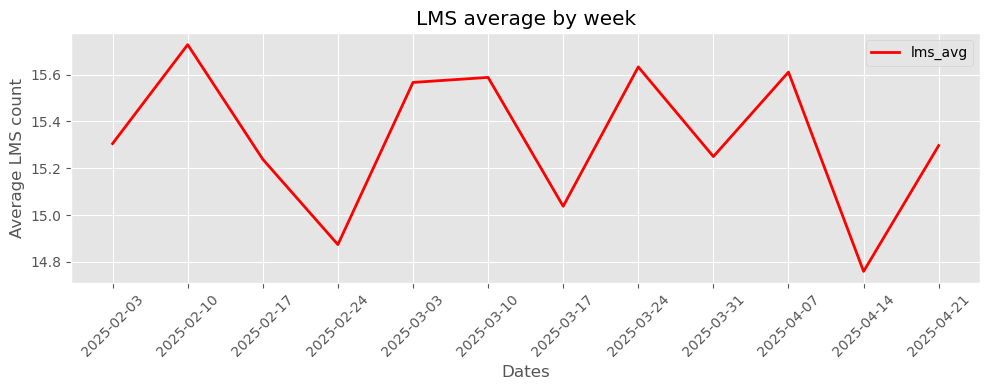

In [334]:
df_week_lms = w_activity_df.groupby("week_start")["lms_logins"].mean()
plt.style.use("ggplot")
plt.figure(figsize=(10,4))
plt.plot(df_week_lms, color = "red", linewidth = 2, label = "lms_avg")
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha = 1.0)
plt.title("LMS average by week")
plt.xlabel("Dates")
plt.ylabel("Average LMS count")
plt.legend()
plt.tight_layout()
#When the weeks continue there is no significant correlations. It just increases or dexreases no pattern.
#But after 2025-04-14 there is significant decreases in lms average something happend.

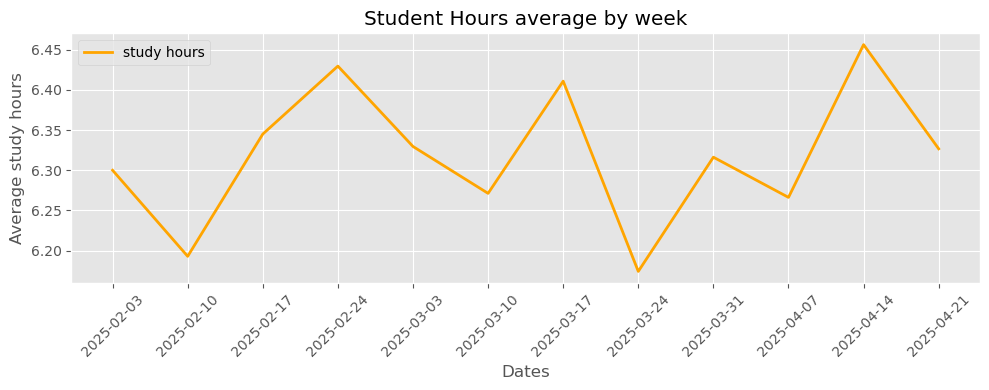

In [335]:
df_week_lms = w_activity_df.groupby("week_start")["study_hours"].mean()
plt.style.use("ggplot")
plt.figure(figsize=(10,4))
plt.plot(df_week_lms, color = "orange", linewidth = 2, label = "study hours")
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha = 1.0)
plt.title("Student Hours average by week")
plt.xlabel("Dates")
plt.ylabel("Average study hours")
plt.legend()
plt.tight_layout()
#In  2025-04-14 average study hours reached its peak level so it might be the final week.

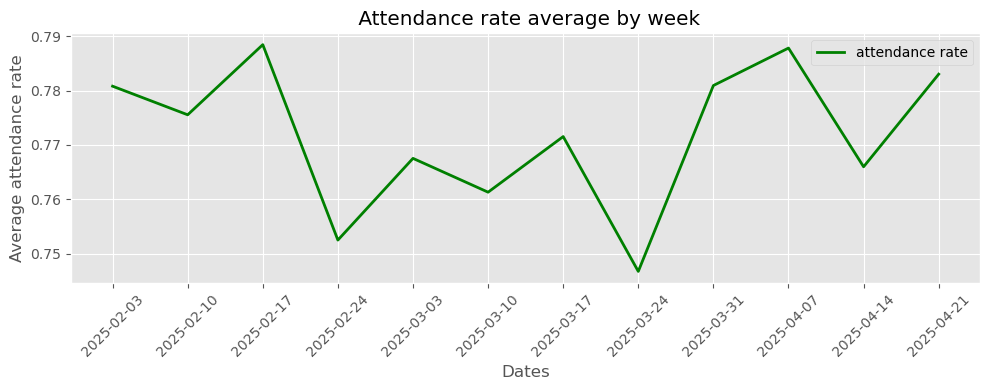

In [336]:
df_week_lms = w_activity_df.groupby("week_start")["attendance_rate"].mean()
plt.style.use("ggplot") 
plt.figure(figsize=(10,4))
plt.plot(df_week_lms, color = "green", linewidth = 2, label = "attendance rate")
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha = 1.0)
plt.title(" Attendance rate average by week")
plt.xlabel("Dates")
plt.ylabel("Average attendance rate")
plt.legend()
plt.tight_layout()
#As i said before it seems before finals attendance rates has increased.

In [337]:
merged_df.columns

Index(['student_id', 'gender', 'department', 'year', 'scholarship_rate',
       'midterm_score', 'project_score', 'quiz_average', 'club_participation',
       'library_visits', 'advisor_meetings', 'study_hours_mean',
       'study_hours_sum', 'lms_logins_mean', 'lms_logins_sum',
       'attendance_rate_mean', 'week_start_count', 'final_score',
       'risk_status', 'high_attendance', 'high_study_hours',
       'engagement_score', 'risk_status_encoded', 'active_campus_user'],
      dtype='object')

In [338]:
three_week_rolling_lms = w_activity_df["lms_logins"].rolling(3).agg(["mean"])
three_week_rolling_lms
#using rolling we calculate each three weeks mean.

,mean
0,NaN
1,NaN
2,12.000000
3,13.333333
4,14.666667
...,...
2875,14.666667
2876,20.000000
2877,20.666667
2878,20.666667


What is Rolling Average:

A rolling average calculates the mean of a fixed-size window of consecutive data points.
As the window slides forward in time, the calculation is updated accordingly.
Why it is Useful:

It smooths out short-term fluctuations and weekly noise, making the underlying trend more visible.
A single unusually low or high week does not distort the overall pattern.
Raw vs Rolling Interpretation:

In the raw weekly data, sharp drops and spikes are visible, such as the decline in week of 2025-02-24.
In the 3-week rolling average, these fluctuations are dampened, revealing that LMS engagement remained
relatively stable throughout the semester with no clear upward or downward trend. 

What is Rolling Average:

A rolling average calculates the mean of a fixed-size window of consecutive data points. As the window slides forward in time, the calculation is updated accordingly.
Why it is Useful:

It smooths out short-term fluctuations and weekly noise, making the underlying trend more visible. A single unusually low or high week does not distort the overall pattern.
Raw vs Rolling Interpretation:

In the raw weekly data, sharp drops and spikes are visible, such as the decline in week of 2025-02-24. In the 3-week rolling average, these fluctuations are dampened, revealing that LMS engagement remained relatively stable throughout the semester with no clear upward or downward trend. 

In [339]:
modified_for_corr_df = merged_df[["study_hours_mean","lms_logins_mean",
                                  "attendance_rate_mean", "midterm_score",
                                  "project_score","quiz_average","library_visits",
                                 "advisor_meetings","final_score"]]
modified_for_corr_df.corr(method="spearman")
#select_dtypes(include="number")

,study_hours_mean,lms_logins_mean,attendance_rate_mean,midterm_score,project_score,quiz_average,library_visits,advisor_meetings,final_score
study_hours_mean,1.000000,0.887909,0.082518,0.092536,0.059805,-0.090153,-0.030721,0.071742,0.459330
lms_logins_mean,0.887909,1.000000,0.030593,0.098986,0.077655,-0.066203,-0.023735,0.085258,0.397052
attendance_rate_mean,0.082518,0.030593,1.000000,-0.031796,-0.025722,-0.066388,-0.016029,0.030546,-0.022512
midterm_score,0.092536,0.098986,-0.031796,1.000000,0.056870,-0.012806,0.007739,-0.056697,0.433869
project_score,0.059805,0.077655,-0.025722,0.056870,1.000000,-0.066027,-0.082497,-0.075086,0.289119
quiz_average,-0.090153,-0.066203,-0.066388,-0.012806,-0.066027,1.000000,-0.061721,0.069907,0.145393
library_visits,-0.030721,-0.023735,-0.016029,0.007739,-0.082497,-0.061721,1.000000,0.051902,0.011296
advisor_meetings,0.071742,0.085258,0.030546,-0.056697,-0.075086,0.069907,0.051902,1.000000,-0.045765
final_score,0.459330,0.397052,-0.022512,0.433869,0.289119,0.145393,0.011296,-0.045765,1.000000


For the first question -> There are two columns have higher positive corr with "Final_score"
    1.study_hours_mean corr_score ->0.459330
    2.midterm_score corr_score -> 0.433869
    these two are the most prominent attributies for final_score

For the second question -> 
    1.For study_hours_mean the corr numbers are very interesting the only strong corr for exams and quiz is the final_score other than that it
    weak. For example, corr between midterm is approximately 0.10. And has perfect corr with lms_logins_mean this is very normal. The more you study you will interact more lms.
    2.Attendance_rate  is very suspicious mostly negative corr with everything.
    Also in earlier cells i detect that if you have lower attendance rate you will get more points.
    Insights might be the don't attend the course and maybe you will get better results.
    3.Also Project_score has same issue other than final_score, study means and lms_logins_mean has negative corr with all. Suspicious!
    4.The most awkward column "quiz_average". How it can be negative corr with all except 2 column. Suspicious!
    
Third question, A strong correlation between study_hours and final_score does not mean that studying more directly causes higher grades.
A third variable, such as student motivation or prior knowledge, may drive both

For the forth question: study_hours_mean,midterm_score, project_score.
These variables showed the strongest correlations with final_score and are therefore the most promising candidates for predictive modeling

In [340]:
merged_df
#risk_status_encoded
#1: Not_At_Risk
#0: At_Risk

#I specified again to remember which one was which.

,student_id,gender,department,year,scholarship_rate,midterm_score,project_score,quiz_average,club_participation,library_visits,...,lms_logins_sum,attendance_rate_mean,week_start_count,final_score,risk_status,high_attendance,high_study_hours,engagement_score,risk_status_encoded,active_campus_user
0,S1000,M,Computer Engineering,2,100.0,43.9,93.7,73.4,Y,13,...,181.0,0.817500,12,86.443755,Not_At_Risk,1,0,65.5,1,1
1,S1001,M,Computer Engineering,2,0.0,67.3,60.9,76.8,N,6,...,226.0,0.787500,12,78.634579,Not_At_Risk,0,1,62.9,1,0
2,S1002,M,Dep-Unknown,2,0.0,49.9,76.6,83.1,N,4,...,162.0,0.818333,12,56.559696,At_Risk,1,0,63.6,0,0
3,S1003,F,Computer Engineering,2,75.0,70.1,42.2,82.0,N,9,...,256.0,0.844167,12,86.158871,Not_At_Risk,1,0,60.0,1,0
4,S1004,F,AI Engineering,2,50.0,56.6,66.5,59.6,Y,1,...,261.0,0.806667,12,68.606180,Not_At_Risk,1,1,58.1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,S1235,M,Dep-Unknown,4,25.0,85.8,49.3,66.5,Y,5,...,167.0,0.774167,12,71.222566,Not_At_Risk,0,0,62.5,1,0
236,S1236,M,AI Engineering,3,50.0,74.2,87.4,60.5,N,11,...,199.0,0.811667,12,84.638368,Not_At_Risk,1,0,70.1,1,0
237,S1237,F,Software Engineering,4,0.0,65.5,73.4,60.8,N,9,...,125.0,0.776667,12,72.375301,Not_At_Risk,0,0,62.6,1,0
238,S1238,F,Computer Engineering,1,0.0,78.3,85.6,71.5,Y,4,...,208.0,0.639167,12,89.100227,Not_At_Risk,0,1,70.9,1,0


In [341]:
# Gender OHE
# Dep OHE
# club_participation OHE
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            240 non-null    object 
 1   gender                240 non-null    object 
 2   department            240 non-null    object 
 3   year                  240 non-null    int64  
 4   scholarship_rate      240 non-null    float64
 5   midterm_score         240 non-null    float64
 6   project_score         240 non-null    float64
 7   quiz_average          240 non-null    float64
 8   club_participation    240 non-null    object 
 9   library_visits        240 non-null    int64  
 10  advisor_meetings      240 non-null    int64  
 11  study_hours_mean      240 non-null    float64
 12  study_hours_sum       240 non-null    float64
 13  lms_logins_mean       240 non-null    float64
 14  lms_logins_sum        240 non-null    float64
 15  attendance_rate_mean  2

In [342]:
gender_ohe = pd.get_dummies(merged_df["gender"],drop_first=True)
club_participation_ohe = pd.get_dummies(merged_df["club_participation"],drop_first=True)
department_ohe = pd.get_dummies(merged_df["department"],drop_first=True)

In [343]:
gender_ohe

,Gender-Unknown,M
0,False,True
1,False,True
2,False,True
3,False,False
4,False,False
...,...,...
235,False,True
236,False,True
237,False,False
238,False,False


One-hot encoding was applied to department, gender, and club_participation variables. drop_first=True was used to avoid multicollinearity. The baseline categories are: AI Engineering for department, Female for gender, and No for club_participation. All other encoded categories are interpreted relative to these baselines."

In [344]:
merged_df = pd.concat([merged_df, gender_ohe, club_participation_ohe, department_ohe], axis=1)
merged_df
#merging into a one file

,student_id,gender,department,year,scholarship_rate,midterm_score,project_score,quiz_average,club_participation,library_visits,...,risk_status_encoded,active_campus_user,Gender-Unknown,M,N,Y,Computer Engineering,Dep-Unknown,Industrial Engineering,Software Engineering
0,S1000,M,Computer Engineering,2,100.0,43.9,93.7,73.4,Y,13,...,1,1,False,True,False,True,True,False,False,False
1,S1001,M,Computer Engineering,2,0.0,67.3,60.9,76.8,N,6,...,1,0,False,True,True,False,True,False,False,False
2,S1002,M,Dep-Unknown,2,0.0,49.9,76.6,83.1,N,4,...,0,0,False,True,True,False,False,True,False,False
3,S1003,F,Computer Engineering,2,75.0,70.1,42.2,82.0,N,9,...,1,0,False,False,True,False,True,False,False,False
4,S1004,F,AI Engineering,2,50.0,56.6,66.5,59.6,Y,1,...,1,0,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,S1235,M,Dep-Unknown,4,25.0,85.8,49.3,66.5,Y,5,...,1,0,False,True,False,True,False,True,False,False
236,S1236,M,AI Engineering,3,50.0,74.2,87.4,60.5,N,11,...,1,0,False,True,True,False,False,False,False,False
237,S1237,F,Software Engineering,4,0.0,65.5,73.4,60.8,N,9,...,1,0,False,False,True,False,False,False,False,True
238,S1238,F,Computer Engineering,1,0.0,78.3,85.6,71.5,Y,4,...,1,0,False,False,False,True,True,False,False,False


In [345]:
Y = merged_df["risk_status_encoded"]
X = merged_df.drop(["student_id","gender","department","club_participation",
                    "risk_status","risk_status_encoded","final_score"],axis=1)

The target variable Y is risk_status_encoded, where 0 represents At_Risk and 1 represents Not_At_Risk students. The feature matrix X includes all available numerical and encoded categorical variables except student_id (identifier), final_score (data leakage — directly determines risk status), and the original categorical columns gender, department, and club_participation which were replaced by their one-hot encoded versions. The goal is to predict academic risk using behavioral, engagement, and assessment features.

In [346]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, random_state=42, test_size = 0.2, stratify=Y)

In [347]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200,300,400],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [1, 5]
}

# GridSearch for better accuracy.
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,              
    scoring='accuracy',
    n_jobs=-1          
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print()
print(grid_search.best_score_)
#I used grid search because it is easy to descide parameters.
#First i did for randomforrest

{'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100}

0.9479082321187583


In [348]:
param_grid = {
    'n_estimators': [100, 200,300,400],
    'max_depth': [3, 5, 10 ,7 ,15],
    "learning_rate" : [0.01, 0.02,0.03]
}

# GridSearch for better accuracy.
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,              
    scoring='accuracy',
    n_jobs=-1          
)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
print()
print(grid_search.best_score_)
#I used grid search because it is easy to descide parameters.
#then i did for xgboost

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

0.9479082321187583


Both Random Forest and XGBoost achieved the same cross-validation accuracy of 0.947. Random Forest was selected as the primary model due to its simplicity, interpretability, and lower risk of overfitting on small datasets. XGBoost, while equally accurate here, requires more careful hyperparameter tuning and is generally more suited for larger and more complex datasets.

In [349]:
RFC = RandomForestClassifier(
    max_depth =  3,
    min_samples_leaf = 1,
    n_estimators = 100
)
RFC.fit(X_train, y_train)
#Establising the model

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [350]:
y_pred = RFC.predict(X_test)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(f"F1 Score for RFC: {f1:.2f}")
print(f"accuracy_score is {accuracy:.2f}")
#Calculating the f1 and accuracy score

F1 Score for RFC: 0.98
accuracy_score is 0.96


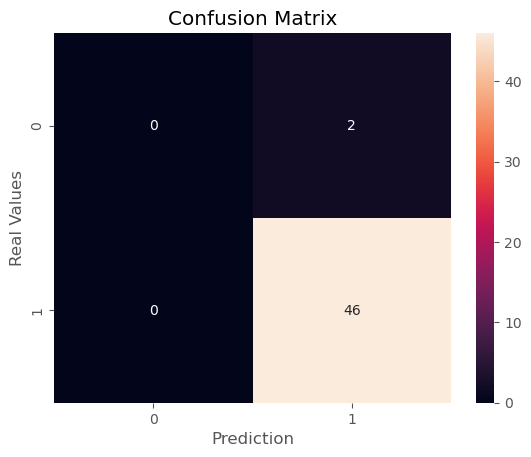

In [351]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm,annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Real Values')
plt.title("Confusion Matrix")
plt.show()
#risk_status_encoded
#1: Not_At_Risk
#0: At_Risk

In [352]:
grades_df["risk_status"].value_counts()

risk_status
Not_At_Risk    228
At_Risk         12
Name: count, dtype: int64

The dataset is severely imbalanced with only 12 At_Risk students out of 240. This means the model rarely encounters At_Risk cases during training, leading to poor recall for the minority class. Techniques such as SMOTE or class weighting could address this in future work.

1. Synthetic Data: The dataset was artificially generated and does not reflect real student behavior. Patterns are too clean and predictable, which inflates model performance metrics.
2. Severe Class Imbalance: Only 12 out of 240 students are labeled At_Risk, representing just 5% of the dataset. This means the model rarely encounters At_Risk cases during training, resulting in poor recall for the minority class. Techniques such as SMOTE or class_weight='balanced' could address this in future work.
3. Small Sample Size: With only 240 students, the model may not generalize well to larger, real-world populations. The test set contains very few At_Risk cases, making evaluation metrics unreliable.
4. Correlated Features: Several features such as study_hours_mean and lms_logins_mean are highly correlated (0.89). This multicollinearity may reduce model interpretability and stability.
5. No External Validation: The model was only evaluated on a single train-test split from the same synthetic dataset. Without external validation on real student data, the model's practical usefulness cannot be confirmed.

In [353]:
merged_df.columns

Index(['student_id', 'gender', 'department', 'year', 'scholarship_rate',
       'midterm_score', 'project_score', 'quiz_average', 'club_participation',
       'library_visits', 'advisor_meetings', 'study_hours_mean',
       'study_hours_sum', 'lms_logins_mean', 'lms_logins_sum',
       'attendance_rate_mean', 'week_start_count', 'final_score',
       'risk_status', 'high_attendance', 'high_study_hours',
       'engagement_score', 'risk_status_encoded', 'active_campus_user',
       'Gender-Unknown', 'M', 'N', 'Y', 'Computer Engineering', 'Dep-Unknown',
       'Industrial Engineering', 'Software Engineering'],
      dtype='object')

In [354]:
clusterData = merged_df[["lms_logins_mean", "library_visits", "study_hours_mean",
                         "final_score", "advisor_meetings", "attendance_rate_mean",
                        "active_campus_user"]]
scaler = StandardScaler()
scaledData = scaler.fit_transform(clusterData)
scaledData
#Scaling the data 

array([[-0.05784402,  2.21492759,  0.43701302, ..., -0.77136431,
         0.98014479,  3.        ],
       [ 0.75437608, -0.35843227,  0.93806862, ..., -0.04821027,
         0.33600917, -0.33333333],
       [-0.40078139, -1.09367794, -0.47030388, ..., -0.77136431,
         0.99803745, -0.33333333],
       ...,
       [-1.06860681,  0.74443624, -0.93073334, ...,  0.67494377,
         0.10340464, -0.33333333],
       [ 0.42948804, -1.09367794,  0.95161066, ..., -0.04821027,
        -2.84888361, -0.33333333],
       [ 0.30314269,  0.74443624,  0.85681636, ..., -0.04821027,
         0.78332557, -0.33333333]], shape=(240, 7))

Feature scaling is necessary for clustering algorithms such as K-Means because the algorithm calculates distances between data points. If features have different scales, for example study_hours ranging from 0 to 15 while lms_logins_sum ranging from 0 to 400, the larger-scale features will dominate the distance calculation and bias the clustering results. By standardizing all features to have zero mean and unit variance, each feature contributes equally to the distance computation.

In [355]:
from sklearn.metrics import silhouette_score
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    prediction = kmeans.fit_predict(scaledData)
    silhouette = silhouette_score(scaledData, kmeans.labels_)
    inerita = kmeans.inertia_
    print(f"K = {k}, Silhouette = {silhouette:.3f}, Inerita = {inerita:.3f}")

K = 2, Silhouette = 0.207, Inerita = 1308.362
K = 3, Silhouette = 0.127, Inerita = 1204.238
K = 4, Silhouette = 0.172, Inerita = 961.475
K = 5, Silhouette = 0.138, Inerita = 1031.885


K=4 was selected as it provides a meaningful balance between cluster separation (silhouette=0.190) and within-cluster compactness (inertia=966), while allowing interpretable and distinct student segments.

In [356]:
kmeans = KMeans(n_clusters=4, random_state=42)
prediction = kmeans.fit_predict(scaledData)

merged_df["Cluster"] = kmeans.labels_
merged_df
#assigning to corresponded column in merged_df

,student_id,gender,department,year,scholarship_rate,midterm_score,project_score,quiz_average,club_participation,library_visits,...,active_campus_user,Gender-Unknown,M,N,Y,Computer Engineering,Dep-Unknown,Industrial Engineering,Software Engineering,Cluster
0,S1000,M,Computer Engineering,2,100.0,43.9,93.7,73.4,Y,13,...,1,False,True,False,True,True,False,False,False,1
1,S1001,M,Computer Engineering,2,0.0,67.3,60.9,76.8,N,6,...,0,False,True,True,False,True,False,False,False,3
2,S1002,M,Dep-Unknown,2,0.0,49.9,76.6,83.1,N,4,...,0,False,True,True,False,False,True,False,False,2
3,S1003,F,Computer Engineering,2,75.0,70.1,42.2,82.0,N,9,...,0,False,False,True,False,True,False,False,False,3
4,S1004,F,AI Engineering,2,50.0,56.6,66.5,59.6,Y,1,...,0,False,False,False,True,False,False,False,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,S1235,M,Dep-Unknown,4,25.0,85.8,49.3,66.5,Y,5,...,0,False,True,False,True,False,True,False,False,2
236,S1236,M,AI Engineering,3,50.0,74.2,87.4,60.5,N,11,...,0,False,True,True,False,False,False,False,False,0
237,S1237,F,Software Engineering,4,0.0,65.5,73.4,60.8,N,9,...,0,False,False,True,False,False,False,False,True,2
238,S1238,F,Computer Engineering,1,0.0,78.3,85.6,71.5,Y,4,...,0,False,False,False,True,True,False,False,False,3


In [357]:
cluster_groupMean = merged_df.groupby("Cluster")[["study_hours_mean", "lms_logins_mean",
    "attendance_rate_mean", "midterm_score", "project_score",
    "quiz_average", "library_visits", "advisor_meetings", "final_score"]].mean()
cluster_groupMean.reset_index()
#for each cluster i calculated selected features mean to understand the pattern.

,Cluster,study_hours_mean,lms_logins_mean,attendance_rate_mean,midterm_score,project_score,quiz_average,library_visits,advisor_meetings,final_score
0,0,5.724495,14.011593,0.799747,64.048485,70.487879,71.036364,8.454545,1.727273,77.201355
1,1,7.525347,18.582260,0.767257,67.237500,72.958333,68.566667,9.791667,2.250000,84.936047
2,2,4.631829,11.061132,0.744618,65.127778,70.045833,70.461111,5.986111,2.083333,72.628186
3,3,8.005876,19.448135,0.774797,69.666667,72.429487,70.566667,5.769231,2.282051,87.043408


In [358]:
cluster_map = {
     0: "Campus Active / Good Performance",
     1: "High Engagement / High Performance", 
     2: "Moderate Engagement / Average Performance",
     3: "Low Engagement / At-Risk"
}
merged_df["Cluster"] = merged_df["Cluster"].map(cluster_map)
merged_df.head(10)
#Assigning new names using map

,student_id,gender,department,year,scholarship_rate,midterm_score,project_score,quiz_average,club_participation,library_visits,...,active_campus_user,Gender-Unknown,M,N,Y,Computer Engineering,Dep-Unknown,Industrial Engineering,Software Engineering,Cluster
0,S1000,M,Computer Engineering,2,100.0,43.9,93.7,73.4,Y,13,...,1,False,True,False,True,True,False,False,False,High Engagement / High Performance
1,S1001,M,Computer Engineering,2,0.0,67.3,60.9,76.8,N,6,...,0,False,True,True,False,True,False,False,False,Low Engagement / At-Risk
2,S1002,M,Dep-Unknown,2,0.0,49.9,76.6,83.1,N,4,...,0,False,True,True,False,False,True,False,False,Moderate Engagement / Average Performance
3,S1003,F,Computer Engineering,2,75.0,70.1,42.2,82.0,N,9,...,0,False,False,True,False,True,False,False,False,Low Engagement / At-Risk
4,S1004,F,AI Engineering,2,50.0,56.6,66.5,59.6,Y,1,...,0,False,False,False,True,False,False,False,False,Low Engagement / At-Risk
5,S1005,F,Dep-Unknown,3,100.0,67.2,74.1,68.5,N,5,...,0,False,False,True,False,False,True,False,False,Low Engagement / At-Risk
6,S1006,F,Computer Engineering,1,0.0,40.8,67.5,63.2,N,12,...,0,False,False,True,False,True,False,False,False,Campus Active / Good Performance
7,S1007,M,Computer Engineering,1,75.0,81.7,56.5,71.9,Y,6,...,0,False,True,False,True,True,False,False,False,Low Engagement / At-Risk
8,S1008,F,Computer Engineering,4,0.0,84.4,62.3,51.3,N,4,...,0,False,False,True,False,True,False,False,False,Low Engagement / At-Risk
9,S1009,M,Industrial Engineering,3,0.0,59.7,57.9,49.3,Y,5,...,0,False,True,False,True,False,False,True,False,Low Engagement / At-Risk


Text(0.5, 1.0, 'scatter plot of average study hours vs final score colored by cluster')

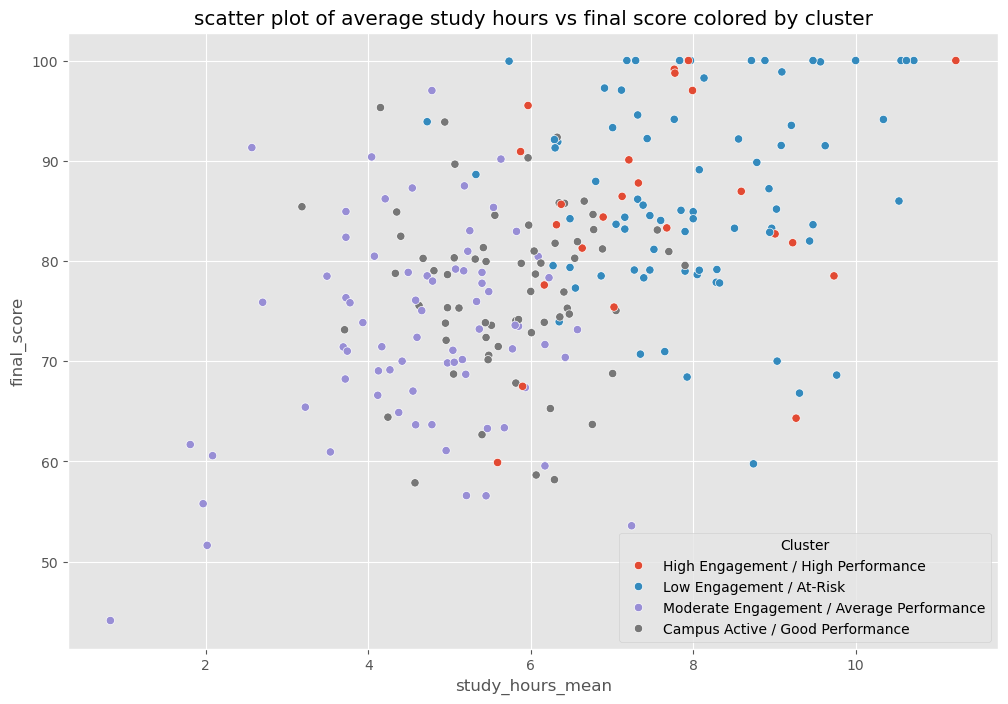

In [359]:
plt.figure(figsize=(12,8))
sns.scatterplot(data = merged_df, x = merged_df["study_hours_mean"],
                y = merged_df["final_score"], hue = merged_df["Cluster"], legend = True)
plt.title("scatter plot of average study hours vs final score colored by cluster")
#using seaborn i created a scatterplot.

## Part 10: Final Discussion and Recommendations

### 1. Data Quality Problems and Solutions
When I first looked at the raw data, I noticed straight away that there were some serious problems that needed fixing before I could do any real analysis. The biggest issues were inconsistent labels in categorical columns, impossible numbers, and missing values scattered across different tables. For example, the gender column had six different ways of writing the same two categories, which pandas treated as completely separate groups. I fixed this using mapping dictionaries to standardize everything into a single format. I also found attendance rates above 1.0, negative LMS login counts, study hours of 80 in a single week, and exam scores above 100, none of which make any sense in reality. I replaced all of these with NaN and then filled them using median imputation. One thing I also noticed was a bug in the original dataset generation code where the activity DataFrame was being recreated inside the for loop. I kept it as it was since it came from the assignment script, but I made sure to document it so it was clear I was aware of it.
### 2. Behavioral and Academic Patterns
The most interesting thing I found during the analysis was that study hours and midterm score were the two variables with the strongest positive correlation with final score, around 0.46 and 0.43 respectively. This tells me that students who put in consistent effort and perform well in assessments tend to get better final results, which makes intuitive sense. What surprised me though was the attendance rate. I expected it to have a strong positive relationship with final score, but it actually showed a near-zero or even slightly negative correlation in some comparisons. When I grouped students by attendance level, I found that students with lower attendance sometimes had higher final scores. My interpretation is that some high-performing students may choose to skip certain classes and study independently, which seems to work out for them. That said, since this is synthetic data, some of these unexpected patterns may just be noise rather than real behavioral signals.
### 3. Classification Model Performance and Practical Usefulness
For the classification task I trained two models, a Random Forest Classifier and an XGBoost Classifier, and compared them using GridSearchCV with 5-fold cross-validation. Both ended up with the same cross-validation accuracy of around 0.947, so I went with Random Forest as my final model since it is simpler and less likely to overfit on a small dataset like this one. On the surface the accuracy looks really good, but when I looked more carefully I realized the result is misleading. The dataset is heavily imbalanced, with only 12 out of 240 students labeled as At_Risk. This means the model almost never sees at-risk cases during training, so it learns to just predict Not_At_Risk most of the time and still gets high accuracy. In a real university setting this would be a serious problem because the whole point of the system is to catch at-risk students early. To actually make this model useful in practice, techniques like SMOTE or class weighting would need to be applied first.
### 4. Meaning of Student Clusters
I used K-Means clustering with k=4 after comparing silhouette scores and inertia values for different values of k. The four clusters I found each represented a clearly different type of student. Cluster 1 had the highest study hours, LMS activity, and final scores, so I labeled it High Engagement and High Performance. Cluster 0 stood out because of its high library visit count alongside good academic results, which suggested these students make active use of campus resources, so I called it Campus Active and Good Performance. Cluster 2 sat in the middle across all metrics with nothing particularly high or low, which I labeled Moderate Engagement and Average Performance. Cluster 3 was the most concerning group with the lowest study hours, lowest LMS logins, and the lowest final scores, so I labeled it Low Engagement and At-Risk. I think clustering is actually more useful than a simple binary risk label in practice because it tells you not just who is struggling, but also why and in what way, which makes it easier to design targeted support.
### 5. Ethical and Practical Concerns
This part of the project made me think beyond just the technical side. Even if a model performs well on paper, using student data to make predictions about academic risk comes with real responsibilities. The first thing I thought about was fairness. A model trained on historical data can easily pick up on patterns that reflect structural disadvantages rather than individual ability. For example, a student working a part-time job might have lower LMS engagement simply because they have less free time, not because they are disengaged or less capable. If the model flags that student as at-risk without any context, that is not a fair or accurate picture. I also thought about privacy. Tracking things like library visits, LMS logins, and attendance means the university is collecting a detailed record of student behavior, and students might not even be fully aware of this. That kind of monitoring can feel uncomfortable if it is not done transparently. The most important thing for me is that these predictions should only ever be used to help students, never to punish them. Risk scores should trigger a friendly outreach from an advisor, an invitation to a tutoring session, or access to extra resources. They should never be used in scholarship decisions or anything that could negatively affect a student's academic standing. If a system like this were ever deployed in a real setting, I would want it to be fully transparent, require student consent, and be regularly checked for bias.